In [1]:
!pip install ultralytics kaggle -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.5 MB/s eta 0:00:00


In [2]:
!kaggle datasets download -d dmtrrmnv/clean-bone-fracture

!unzip -q clean-bone-fracture.zip -d data
!rm clean-bone-fracture.zip

!ls data

Dataset URL: https://www.kaggle.com/datasets/dmtrrmnv/clean-bone-fracture
License(s): MIT
100% 196M/196M [00:10<00:00, 19.6MB/s]

data


In [3]:
from ultralytics import YOLO
import torch

def main():
    # Проверка CUDA
    print(f"CUDA доступна: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

    # Загрузка модели
    model = YOLO("yolov8m.pt")

    # Обучение
    results = model.train(
        data="data/data/data.yaml",
        epochs=40,
        imgsz=640,
        batch=32,
        optimizer="AdamW",
        lr0=0.001,
        lrf=0.01,
        mosaic=1.0,
        mixup=0.2,
        cutmix=0.2,
        auto_augment="randaugment",
        hsv_s=0.1,
        hsv_v=0.1,
        warmup_epochs=3,
        weight_decay=0.0005,
        device=0,
        workers=8,
        save=True,
        plots=True,
        project="runs/train",
        name="clean_fracture_run",
        exist_ok=False,
        verbose=True
    )

    print(f"\n✅ Обучение завершено!")
    print(f"📁 Результаты сохранены в: {results.save_dir}")
    print(f"🏆 Лучшая модель: {results.save_dir / 'weights' / 'best.pt'}")

if __name__ == "__main__":
    main()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA доступна: True
GPU: Tesla T4
VRAM: 14.6 GB
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.2, data=data/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.

In [5]:
from google.colab import files
files.download("/content/runs/detect/runs/train/clean_fracture_run/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Используется устройство: 0
Модель загружена: /content/runs/detect/runs/train/clean_fracture_run/weights/best.pt
Найдено изображений: 134
Найдены аннотации – будут вычислены метрики.

image 1/134 /content/data/data/test/images/BF1800_000041.jpg: 640x640 1 normal, 36.8ms
image 2/134 /content/data/data/test/images/BF1800_000042.jpg: 640x640 1 normal, 35.3ms
image 3/134 /content/data/data/test/images/BF1800_000043.jpg: 640x640 1 normal, 35.3ms
image 4/134 /content/data/data/test/images/BF1800_000044.jpg: 640x640 1 fracture, 35.2ms
image 5/134 /content/data/data/test/images/BF1800_000045.jpg: 640x640 1 fracture, 1 normal, 35.2ms
image 6/134 /content/data/data/test/images/BF1800_000046.jpg: 640x640 1 normal, 28.8ms
image 7/134 /content/data/data/test/images/BF1800_000047.jpg: 640x640 1 normal, 20.9ms
image 8/134 /content/data/data/test/images/BF1800_000048.jpg: 640x640 1 normal, 22.3ms
image 9/134 /content/data/data/test/images/BF1800_000049.jpg: 640x640 1 fracture, 20.5ms
image 10/134 /cont

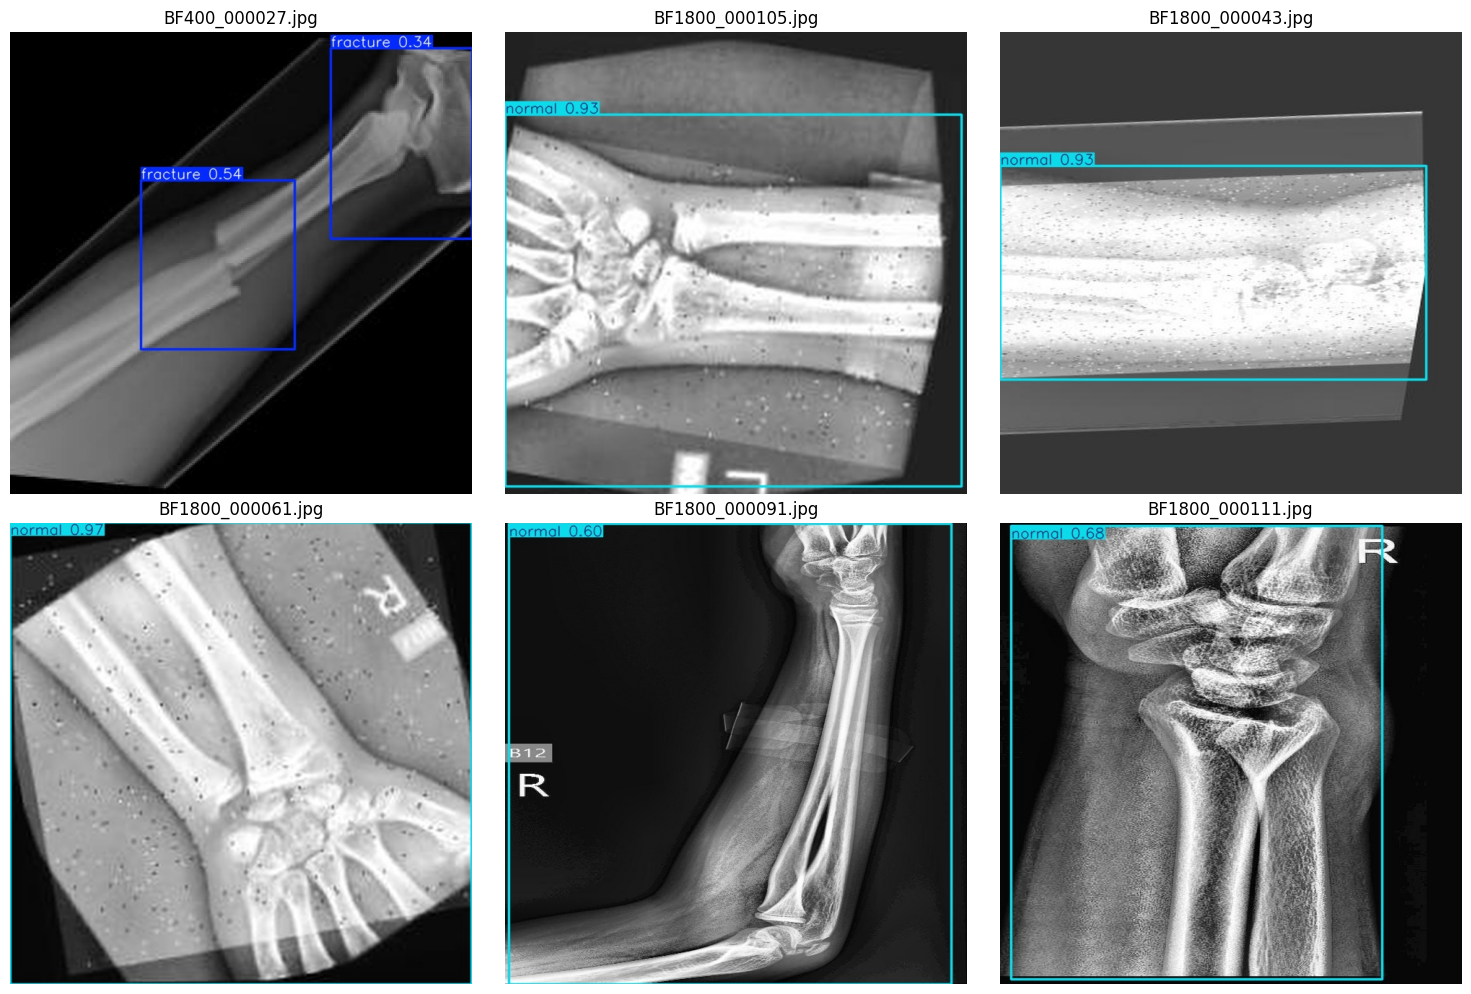

📸 Примеры предсказаний сохранены в: /content/runs/detect/test_results/sample_predictions.png


In [9]:
import os
import cv2
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

def main():
    # Пути
    MODEL_PATH = "/content/runs/detect/runs/train/clean_fracture_run/weights/best.pt"
    TEST_IMAGES_DIR = "data/data/test/images"
    TEST_LABELS_DIR = "data/data/test/labels"
    OUTPUT_DIR = "/content/runs/detect/test_results"

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    device = 0 if torch.cuda.is_available() else 'cpu'
    print(f"Используется устройство: {device}")

    model = YOLO(MODEL_PATH)
    print(f"Модель загружена: {MODEL_PATH}")

    image_files = [f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    print(f"Найдено изображений: {len(image_files)}")

    has_labels = os.path.exists(TEST_LABELS_DIR)
    if has_labels:
        print("Найдены аннотации – будут вычислены метрики.")
    else:
        print("Аннотации не найдены – будет только визуализация.")

    results = model.predict(
        source=TEST_IMAGES_DIR,
        imgsz=640,
        conf=0.25,
        iou=0.45,
        save=True,
        save_txt=True,
        save_conf=True,
        project=OUTPUT_DIR,
        name="predictions",
        exist_ok=True,
        show_labels=True,
        show_conf=True
    )

    print(f"\nПредсказания сохранены в: {OUTPUT_DIR}/predictions")

    if has_labels:
        print("\nОценка модели на тестовой выборке...")
        metrics = model.val(
            data="data/data/data.yaml",
            split="test",
            batch=16,
            imgsz=640,
            conf=0.25,
            iou=0.45,
            device=device,
            plots=True,
            project=OUTPUT_DIR,
            name="metrics"
        )
        print(f"Метрики (mAP50): {metrics.box.map50:.4f}")
        print(f"Метрики (mAP50-95): {metrics.box.map:.4f}")
        print(f"Precision: {metrics.box.mp:.4f}")
        print(f"Recall: {metrics.box.mr:.4f}")
        print(f"Графики сохранены в: {OUTPUT_DIR}/metrics")


    print("\n🖼️ Визуализация первых 6 предсказаний...")
    pred_dir = os.path.join(OUTPUT_DIR, "predictions")
    pred_images = [f for f in os.listdir(pred_dir) if f.endswith('.jpg') or f.endswith('.png')]
    sample = pred_images[:6]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, img_name in enumerate(sample):
        img_path = os.path.join(pred_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(img_name)
        axes[idx].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions.png"), dpi=150)
    plt.show()
    print(f"Примеры предсказаний сохранены в: {OUTPUT_DIR}/sample_predictions.png")
